# Proyecto MD - Predictor del autismo en personas

1. [Introducción](#introduccion)

   1.1 [Preparador](#preparador)

   1.2 [Análisis de variables](#analisis_variables)

2. [Pipeline](#pipeline)

   2.1 [Componentes](#componentes)

   2.2 [Métricas de validación y evaluación](#metricas)

   2.3 [Construcción de prototipos](#prototipos)

3. [Análisis](#analisis)

   3.1 [Análisis de la pipeline base](#modelo_base)

   3.2 [Análisis del componente Detector de Outliers](#outliers)

   3.3 [Análisis del componente Estandarizador](#estandarizador)

   3.4 [Análisis de la pipeline avanzada](#pipeline_avanzada)

   3.5 [Análisis del componente Modelo](#modelo)

   3.6 [Análisis del umbral](#umbral)

   3.7 [Mejor pipeline](#mejor_pipeline)

4. [Experimentos](#experimentos)

   4.1 [Experimento en test](#experimento_test)
   
   4.2 [Experimento con nosotros](#experimento_nosotros)

5. [Conclusiones](#conclusiones)

<a id="introduccion"></a>
# 1. Introducción

El problema elegido para este proyecto es la **predicción del autismo en personas** a partir del dataset `Autism-Adult-Data.csv`.

Para realizar lo anterior, haremos lo siguiente:
* Analizar nuestro problema
* Crear la mejor pipeline posible
* Reflexionar qué tan buena es la solución

### Configuración inicial

In [48]:
import warnings

import shap
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# from classes import Preparador, Imputer, Transformador, OutlierDetector

from sklearn.tree import DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_recall_curve, make_scorer, average_precision_score

seed = 123
np.random.seed(123)
test_size = 0.2

# warnings.filterwarnings("ignore") #(Para surprimir los warnings)

<a id="preparador"></a>
## 1.1 Preparador

Para comenzar, vamos a crear una clase denominada "Preparador", cuyo fin es ganar orden y limpieza
en nuestro dataset, pero sin cambiar ningún dato que pueda afectar a la solución final.

Realiza lo siguiente:
* Renombra columnas
* Elimina columnas innecesarias
* Pone a las columnas a1_score...a10_score: 0 => No, 1 => Si
* Limpia el texto de cada columna
* Convierte los valores perdidos: "?" => NaN
* Formatea columnas: category, float32

Se puede ejecutar para ver el antes y el después del dataset.

In [49]:
import numpy as np
import pandas as pd
from sklearn.base import TransformerMixin, BaseEstimator

class Preparador(TransformerMixin, BaseEstimator):
    def __init__(self):
        pass

    def preparar(self, X: pd.DataFrame):
        X = self.__rename(X)
        X = self.__column_del(X)
        X = self.__invert_meaning_answers(X)
        X = self.__clean_text(X)
        X = self.__replace_missing(X)
        X = self.__type_variables(X)
        return X
    
    def __rename(self, X: pd.DataFrame):
        """Pasa todas las columnas a minuscula y renombra las columnas con nombres erróneos"""
        Xaux = X.rename(columns=dict((col, col.lower()) for col in X.columns))
        Xaux = Xaux.rename(columns={'jundice': 'jaundice', 'austim': 'family_pdd', 'contry_of_res': 'country_of_res', 'class/asd': 'class'})
        return Xaux
    
    def __column_del(self, X: pd.DataFrame):
        """ Elimina las columnas """
        X = X.drop(columns=["id", "result", "age_desc"])
        return X

    def __invert_meaning_answers(self, X: pd.DataFrame):
        """ En info/Dataset_Autism.pdf se explica que las siguientes columnas tienen los valores "al revés" """
        cols = ["a2_score", "a3_score", "a4_score", "a5_score", "a6_score", "a9_score"]
        X[cols] = np.abs(X[cols] - 1)
        return X
    
    def __type_variables(self, X: pd.DataFrame):
        """ Pasa las variables a categoricas y numéricas a dichos tipos """
        cols_score = ["a1_score", "a2_score", "a3_score", "a4_score", "a5_score",
                "a6_score", "a7_score", "a8_score", "a9_score", "a10_score"]
        X[cols_score] = np.where(X[cols_score] == 1, "agree", "disagree")

        cols_cat = ["a1_score", "a2_score", "a3_score", "a4_score", "a5_score",
                "a6_score", "a7_score", "a8_score", "a9_score", "a10_score",
                "gender", "ethnicity", "jaundice", "family_pdd", "country_of_res",
                "used_app_before", "relation", "class"]
        X[cols_cat] = X[cols_cat].astype('category')

        cols_num = ["age"]
        X[cols_num] = X[cols_num].apply(pd.to_numeric, errors='coerce').astype(np.float32)
        return X

    def __clean_text(self, X: pd.DataFrame):
        """Minimiza, borra espacios y convierte '?' en NaN"""
        cols = ['gender', 'ethnicity', 'jaundice', 'family_pdd', 'country_of_res', 'used_app_before', 'relation', 'class']
        X[cols] = X[cols].apply(lambda x: x.str.lower().str.replace(" ", "", regex=False))
        return X
    
    def __replace_missing(self, X: pd.DataFrame):
        """Convierte los '?' en NaN para que el imputador los detecte"""
        X = X.replace('?', np.nan) # ===============================================================================
        return X
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self.preparar(X)

if __name__ == '__main__':
    df = pd.read_csv("Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()

    print("============================")
    print("    DATASET ORIGINAL ")
    print("============================\n")
    df.info()

    print("\n---------------------------- DOMINIO DE VARIABLES ----------------------------\n")
    print("A1_Score...A10_Score: ", np.unique(df["A1_Score"]))
    print("age: ", np.unique(df["age"]))
    print("gender: ", np.unique(df["gender"]))
    print("ethnicity: ", np.unique(df["ethnicity"]))
    print("jundice: ", np.unique(df["jundice"]))
    print("austim: ", np.unique(df["austim"]))
    print("contry_of_res: ", np.unique(df["contry_of_res"]))
    print("used_app_before: ", np.unique(df["used_app_before"]))
    print("relation: ", np.unique(df["relation"]))
    print("Class/ASD: ", np.unique(df["Class/ASD"]))

    df = preparador.preparar(df)

    print("\n")
    print("============================")
    print("    DATASET PREPARADO ")
    print("============================\n")
    df.info()

    print("\n---------------------------- DOMINIO DE VARIABLES ----------------------------\n")
    print("a1_score...a10_score: ", list(df["a1_score"].cat.categories))
    print("age: ", np.unique(df["age"]))
    print("gender: ", list(df["gender"].cat.categories))
    print("ethnicity: ", list(df["ethnicity"].cat.categories))
    print("jaundice: ", list(df["jaundice"].cat.categories))
    print("family_pdd: ", list(df["family_pdd"].cat.categories))
    print("country_of_res: ", list(df["country_of_res"].cat.categories))
    print("used_app_before: ", list(df["used_app_before"].cat.categories))
    print("relation: ", list(df["relation"].cat.categories))
    print("class: ", list(df["class"].cat.categories))

    print("\nNota: Los valores perdidos en las variables category no se ven, pero en realidad existen, se puede ver arriba en la columna \"Non-Null Count\"")

    DATASET ORIGINAL 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               704 non-null    int64 
 1   A1_Score         704 non-null    int64 
 2   A2_Score         704 non-null    int64 
 3   A3_Score         704 non-null    int64 
 4   A4_Score         704 non-null    int64 
 5   A5_Score         704 non-null    int64 
 6   A6_Score         704 non-null    int64 
 7   A7_Score         704 non-null    int64 
 8   A8_Score         704 non-null    int64 
 9   A9_Score         704 non-null    int64 
 10  A10_Score        704 non-null    int64 
 11  age              704 non-null    object
 12  gender           704 non-null    object
 13  ethnicity        704 non-null    object
 14  jundice          704 non-null    object
 15  austim           704 non-null    object
 16  contry_of_res    704 non-null    object
 17  used_app_bef

<a id="analisis_variables"></a>
## 1.2 Análisis de variables

Una vez construido nuestro Preparador, vamos a analizar las variables de entrada y su relación con la variable de salida.

Como nota, cuando pongamos __"↑ Autismo"__ o __"↓ Autismo"__, nos referiremos a un aumento o disminución de la probabilidad de tenerlo.

In [50]:
preparador = Preparador()

df = pd.read_csv("Autism-Adult-Data.csv", delimiter=',')
df = preparador.preparar(df)

X, y = df[df.columns[:-1]], df[df.columns[-1]]

X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

y_resto = y_resto.map({'no': 0, 'yes': 1})
y_test = y_test.map({'no': 0, 'yes': 1})

X_analisis = X_resto.copy()
y_analisis = y_resto.copy()

In [51]:
def dibujar_relacion_variable_entrada_con_salida(X: pd.DataFrame, col: str, title: str, legend: bool, ax=None):
    if ax is None:
        fig, ax = plt.subplots(2, 5, figsize=(15, 6))
        axes = ax.ravel()
    
    ct = pd.crosstab(X[col], y_analisis)
    ct.columns = ["hasn't autism", "has autism"]
    ct.plot(kind="bar", ax=ax, legend=legend)
    ax.set_title(title)
    ax.set_xlabel("")
                
    return ax

### Relación de las 10 preguntas con la variable de salida

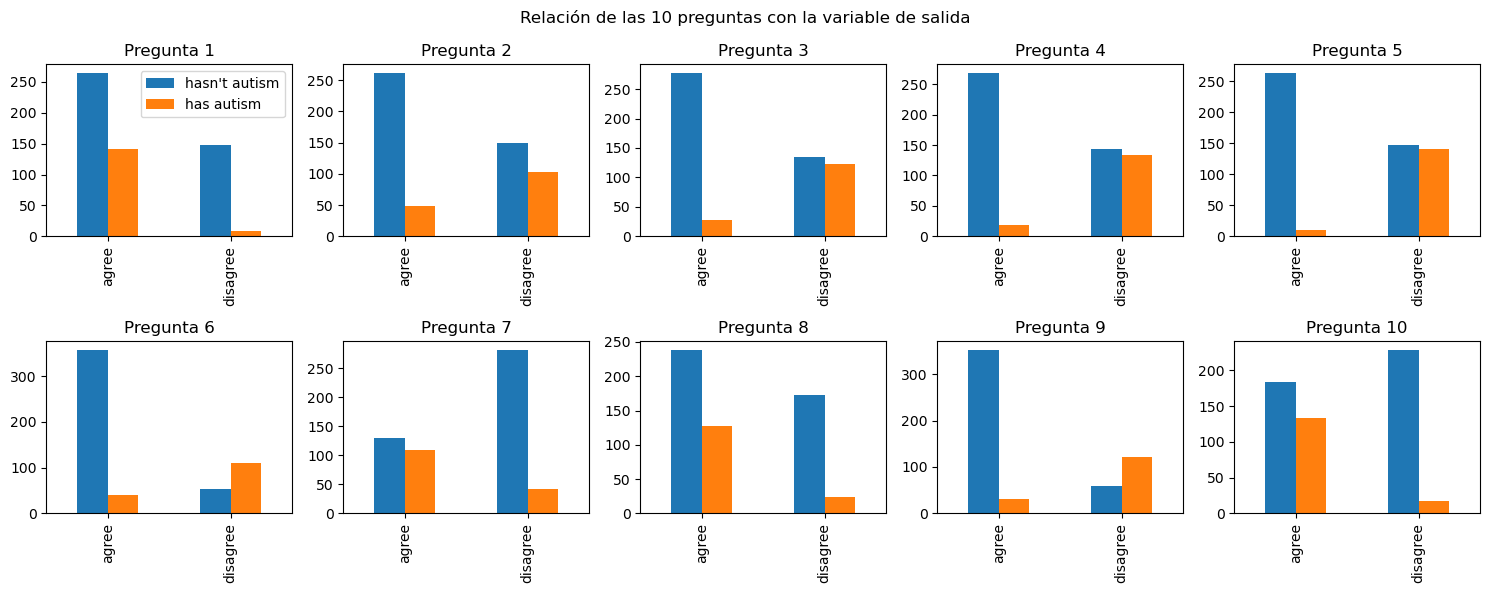

In [52]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    col = X_analisis.columns[i]
    dibujar_relacion_variable_entrada_con_salida(X_analisis, col, f"Pregunta {i+1}", legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las 10 preguntas con la variable de salida")                   
fig.tight_layout()
plt.show()

<div style="display: flex; justify-content: center;">

| # | Pregunta | Dirección |
|---|---|---|
| 1 | I often notice small sounds when others do not. | Agree → ↑ Autismo |
| 2 | I usually concentrate more on the whole picture, rather than the small details. | Agree → ↓ Autismo |
| 3 | I find it easy to do more than one thing at once. | Agree → ↓ Autismo |
| 4 | If there is an interruption, I can switch back to what I was doing very quickly. | Agree → ↓ Autismo |
| 5 | I find it easy to read between the lines when someone is talking to me. | Agree → ↓ Autismo |
| 6 | I know how to tell if someone listening to me is getting bored. | Agree → ↓ Autismo |
| 7 | When I’m reading a story, I find it difficult to work out the characters’ intentions. | Agree → ↑ Autismo |
| 8 | I like to collect information about categories of things. | Agree → ↑ Autismo |
| 9 | I find it easy to work out what someone is thinking or feeling just by looking at their face. | Agree → ↓ Autismo |
| 10 | I find it difficult to work out people’s intentions. | Agree → ↑ Autismo |

</div>

### Relación de las variables binarias con la variable de salida

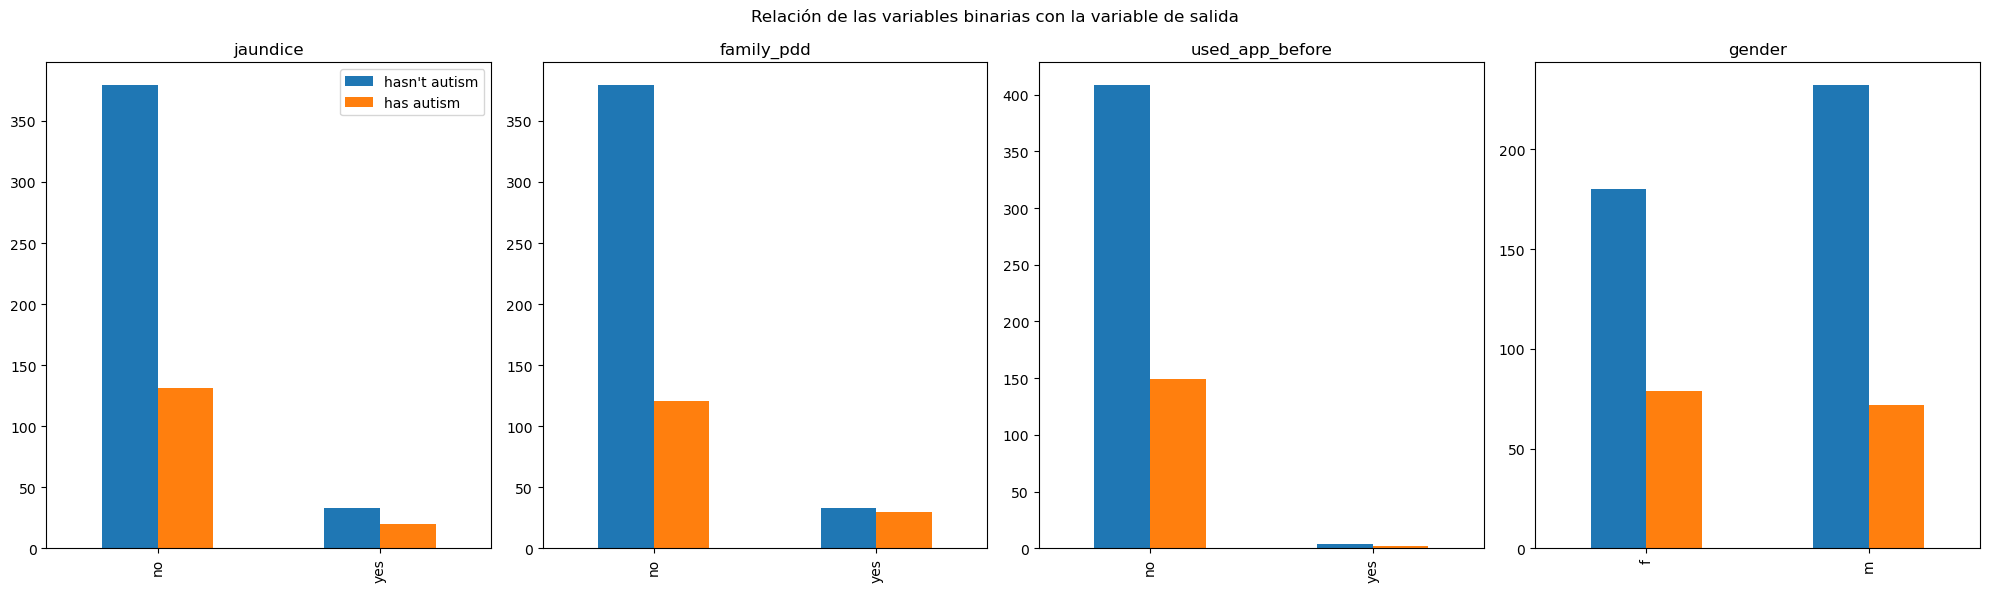

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.ravel()

cols = ["jaundice", "family_pdd", "used_app_before", "gender"]
for i, col in enumerate(cols):
    dibujar_relacion_variable_entrada_con_salida(X_analisis, col, col, legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las variables binarias con la variable de salida")
fig.tight_layout()
plt.show()

<div style="display: flex; justify-content: center;">

| Caracteristica | Dirección |
|---|---|
| Jaundice (Ictericia) | yes → ↑ Autismo |
| Family pdd | yes → ↑ Autismo |
| Used app before | yes → ↑ Autismo |
| Gender | m → ↓ Autismo |

</div>

#### App a la que hace referencia la columna

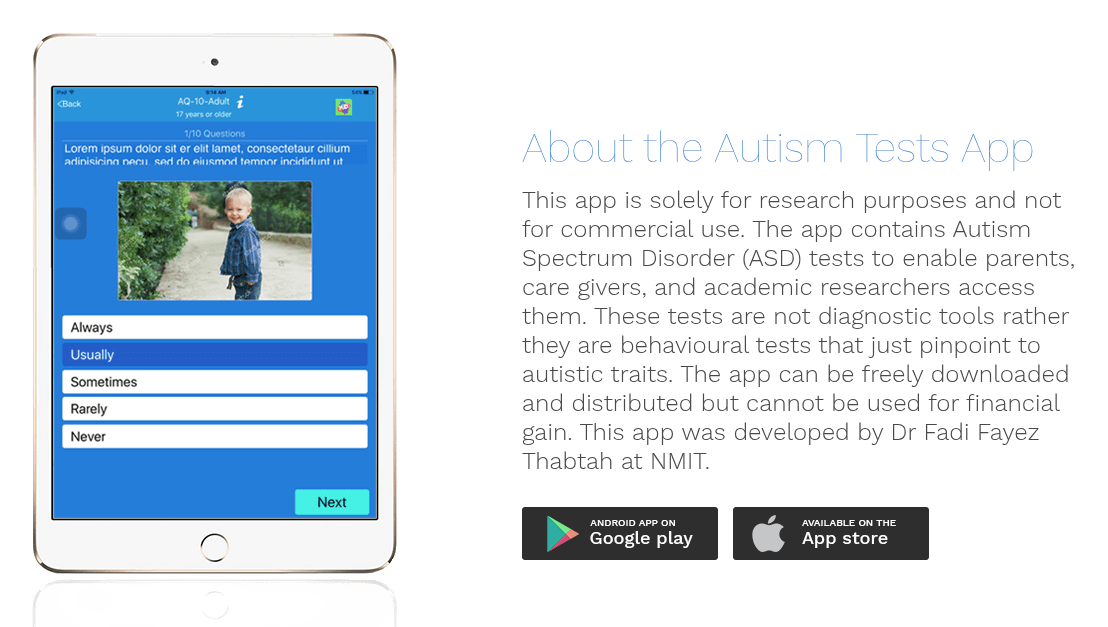

### Relación de las variables restantes con la variable de salida

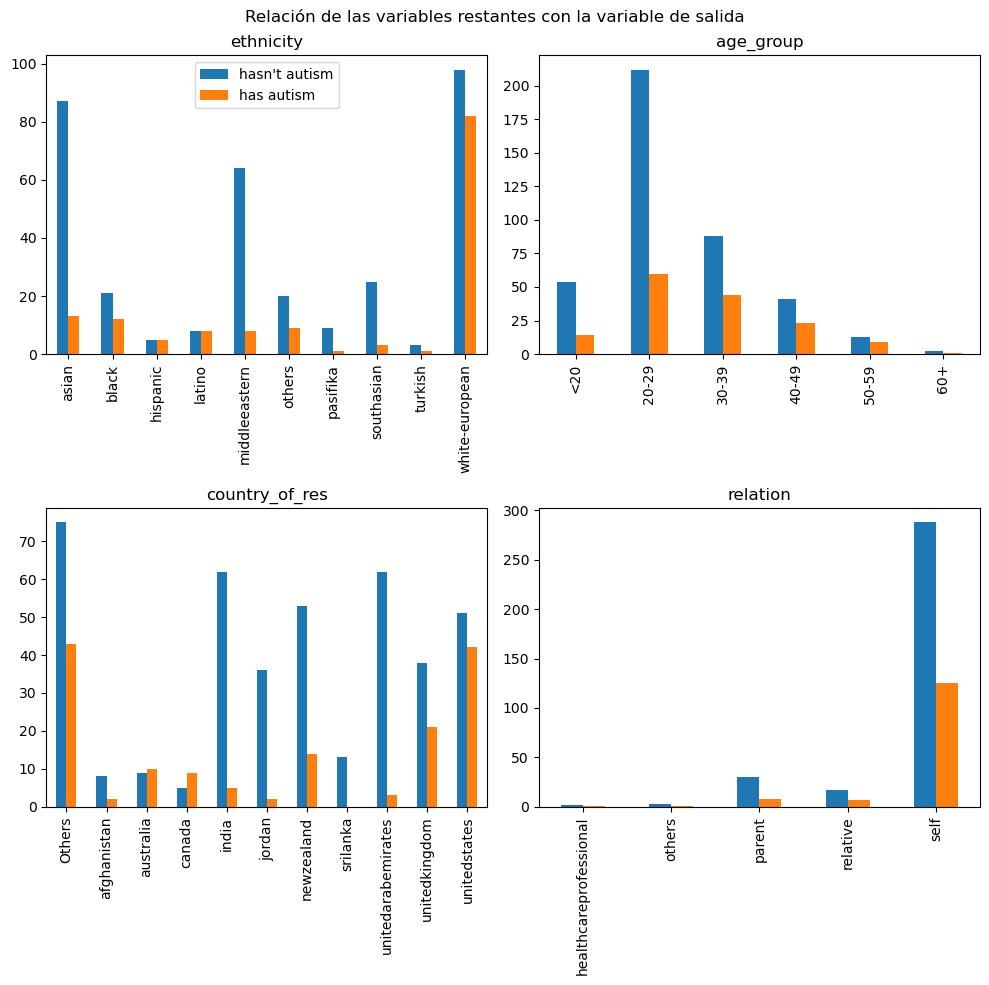

In [54]:
# Formateamos resultados
Xaux = X_analisis.copy()
bins = [0, 19, 29, 39, 49, 59, 1000] 
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
Xaux["age_group"] = pd.cut(Xaux["age"], bins=bins, labels=labels)

top_countries = Xaux["country_of_res"].value_counts().nlargest(10).index
Xaux["country_of_res"] = Xaux["country_of_res"].apply(lambda x: x if x in top_countries else "Others")

# Mostramos los graficos
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

cols = ["ethnicity", "age_group", "country_of_res", "relation"]
for i, col in enumerate(cols):
    dibujar_relacion_variable_entrada_con_salida(Xaux, col, col, legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las variables restantes con la variable de salida")
fig.tight_layout()
plt.show()

Nota: En la etnia, pais de residencia y relacion hay pocos datos de cada categoria, por lo que los resultados pueden ser engañosos.

* Ethnicity:
    * ↑ Autismo: black, hispanic, latino, white-european.
    * ↓ Autismo: middleeastem, pasifika, southasian, turkish.

* Age group:
    * ↑ Autismo: De 30 hacia arriba.
    * ↓ Autismo: De 30 hacia abajo.

* Country of residence (Mostramos los 10 paises con más datos):
    * ↑ Autismo: australia, canada, unitedkingdom, unitedstates
    * ↓ Autismo: afghanistan, india, jordan, newzealand, srilanka, unitedarabemirates

* Relation: No aporta demasiada información porque la mayoría de ejemplos pertenecen a la categoría "self",
por lo que no hay una gran variedad de información, por ello en la siguiente celda la eliminamos.

In [55]:
X_resto = X_resto.drop(columns=["relation"])
X_test = X_test.drop(columns=["relation"])

<a id="pipeline"></a>
# 2. Pipeline

A continuación, presentaremos toda la infraestructura creada para poder resolver el problema de la forma más eficiente posible.

Para evitar usar información del test en las decisiones de análisis, los conjuntos `test` y `resto` ya se han creado antes del análisis de variables.

In [56]:
# El split ya se ha realizado antes del análisis de variables para evitar usar test en las decisiones de EDA.

<a id="componentes"></a>
## 2.1 Componentes

Los componentes principales son:

- **Imputer**: trata los valores perdidos en variables numéricas y categóricas.
- **Transformador**: convierte variables categóricas a una representación numérica.
- **OutlierDetector**: detecta y reemplaza valores atípicos.
- **Estandarizador**: escala las variables numéricas para mejorar el comportamiento de KNN.
- **Modelo (KNN o Árbol de decisión)**: modelo base utilizado para la clasificación.

### Imputador

In [57]:
from sklearn.base import TransformerMixin, BaseEstimator
from typing import Literal
import numpy as np
import pandas as pd

class Imputer(TransformerMixin, BaseEstimator):
	"""Imputador de valores perdidos para variables categóricas y numéricas por distintos métodos"""
	def __init__(
			self,
			metodo_imputacion_vars_num: Literal["media", "mediana"]="mediana",
			metodo_imputacion_vars_cat: Literal["moda", "missing"]="missing"
		) -> None:

		self._opciones_met_imp_vars_num = ["media", "mediana"]
		self._opciones_met_imp_vars_cat = ["moda", "missing"]
        
		if metodo_imputacion_vars_num not in self._opciones_met_imp_vars_num:
			raise ValueError(f"[ERROR]: La opción de imputación numérica '{metodo_imputacion_vars_num}' \
					no está disponible. Usar solo [{', '.join(self._opciones_met_imp_vars_num)}]")
		if metodo_imputacion_vars_cat not in self._opciones_met_imp_vars_cat:
			raise ValueError(f"[ERROR]: La opción de imputación categórica '{metodo_imputacion_vars_cat}' \
					no está disponible. Usar solo [{', '.join(self._opciones_met_imp_vars_cat)}]")
		
		self.metodo_imputacion_vars_num = metodo_imputacion_vars_num
		self.metodo_imputacion_vars_cat = metodo_imputacion_vars_cat

		self._valores_imputacion_vars_num = {}
		self._valores_imputacion_vars_cat = {}

	def fit(self, X, y=None):
		for nombre_columna in X.columns:
			if X[nombre_columna].dtype == "category":
				if self.metodo_imputacion_vars_cat == "moda":
					self._valores_imputacion_vars_cat[nombre_columna] = (
						X[nombre_columna].dropna().mode()[0]
					)
				else:
					self._valores_imputacion_vars_cat[nombre_columna] = "missed"
			else:
				if self.metodo_imputacion_vars_num == "media":
					self._valores_imputacion_vars_num[nombre_columna] = np.nanmean(X[nombre_columna])
				else:
					self._valores_imputacion_vars_num[nombre_columna] = np.nanmedian(X[nombre_columna])
		return self
	
	def transform(self, X: pd.DataFrame):
		Xaux = pd.DataFrame(X).copy()
		
		for nombre_columna in self._valores_imputacion_vars_cat.keys():
			Xaux[nombre_columna] = Xaux[nombre_columna].astype("object")
			Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_cat[nombre_columna]
			Xaux[nombre_columna] = Xaux[nombre_columna].astype("category")

		for nombre_columna in self._valores_imputacion_vars_num.keys():
			Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_num[nombre_columna]

		return Xaux

if __name__ == '__main__':
    df = pd.read_csv("Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()
    df = preparador.preparar(df)

    print("============================")
    print("    SIN IMPUTACIÓN ")
    print("============================\n")
    df.info()

    imputer = Imputer(metodo_imputacion_vars_num="mediana", metodo_imputacion_vars_cat="moda")
    df = imputer.fit_transform(df)

    print("\n")
    print("============================")
    print("    CON IMPUTACIÓN ")
    print("============================\n")
    df.info()

    SIN IMPUTACIÓN 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   a1_score         704 non-null    category
 1   a2_score         704 non-null    category
 2   a3_score         704 non-null    category
 3   a4_score         704 non-null    category
 4   a5_score         704 non-null    category
 5   a6_score         704 non-null    category
 6   a7_score         704 non-null    category
 7   a8_score         704 non-null    category
 8   a9_score         704 non-null    category
 9   a10_score        704 non-null    category
 10  age              702 non-null    float32 
 11  gender           704 non-null    category
 12  ethnicity        609 non-null    category
 13  jaundice         704 non-null    category
 14  family_pdd       704 non-null    category
 15  country_of_res   704 non-null    category
 16  used_app_before  704 no

### Transformador

In [58]:
import numpy as np
import pandas as pd

from typing import Literal
from sklearn.base import TransformerMixin, BaseEstimator

class Transformador(TransformerMixin, BaseEstimator):

    def __init__(self, metodo_cat_num: Literal["orden", "conteo", "ohe", "binary"]="orden") -> None:
        opciones = ["orden", "conteo", "ohe", "binary"]
        
        if metodo_cat_num not in opciones:
            raise ValueError(f"[ERROR]: La opción de imputación numérica '{metodo_cat_num}' \
                    no está disponible. Usar solo [{', '.join(opciones)}]")
        
        self.metodo_cat_num = metodo_cat_num
        self._correspondencias = {}

    def fit(self, X: pd.DataFrame, y=None):
        self._correspondencias = {}
        columnas_cat = X.select_dtypes(include='category').columns
        for col in columnas_cat:
            categorias = list(X[col].dropna().unique())
            if self.metodo_cat_num == "orden":
                mapping = {}
                for i, cat in enumerate(categorias):
                    mapping[cat] = i
                self._correspondencias[col] = mapping

            elif self.metodo_cat_num == "conteo":
                mapping = {}
                conteo = X[col].value_counts()
                for cat in conteo.index:
                    mapping[cat] = conteo[cat]
                self._correspondencias[col] = mapping

            elif self.metodo_cat_num == "ohe":
                self._correspondencias[col] = categorias

            elif self.metodo_cat_num == "binary":
                mapping = {}
                for i, cat in enumerate(categorias):
                    mapping[cat] = i

                # Bits necesarios
                n = len(categorias)
                bits = int(np.ceil(np.log2(n))) if n > 1 else 1
                self._correspondencias[col] = {
                    "mapping": mapping,
                    "bits": bits
                }

        return self

    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        for col in Xaux.select_dtypes("category").columns:
            Xaux[col] = Xaux[col].astype(object)

        new_cols = {}
        cols_to_drop = []
        for col in list(self._correspondencias.keys()):
            if self.metodo_cat_num in ["orden", "conteo"]:
                mapping = self._correspondencias[col]
                Xaux[col] = Xaux[col].map(mapping).fillna(-1).astype("float32")

            elif self.metodo_cat_num == "ohe":
                categorias = self._correspondencias[col]
                for cat in categorias:
                    new_cols[f"{col}_{cat}"] = (Xaux[col] == cat).astype("float32")
                cols_to_drop.append(col)

            elif self.metodo_cat_num == "binary":
                info = self._correspondencias[col]
                mapping = info["mapping"]
                bits = info["bits"]

                numeros = Xaux[col].map(mapping).fillna(0).astype(np.int64).to_numpy()
                for i in range(bits):
                    new_cols[f"{col}_bit_{i}"] = ((numeros >> i) & 1).astype("float32")
                cols_to_drop.append(col)

        if cols_to_drop:
            Xaux = Xaux.drop(columns=cols_to_drop)
        if new_cols:
            Xaux = pd.concat([Xaux, pd.DataFrame(new_cols, index=Xaux.index)], axis=1)

        return Xaux
    
if __name__ == '__main__':
    df = pd.read_csv("Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()
    df = preparador.preparar(df)

    print("=============================")
    print("    SIN TRANSFORMACION")
    print("=============================\n")

    imputer = Imputer()
    df = imputer.fit_transform(df)
    df.info()

    
    print("\n=============================")
    print("    CON TRANSFORMACION")
    print("=============================")
    
    transformador = Transformador(metodo_cat_num="orden")
    df = transformador.fit_transform(df)
    df.info()

    SIN TRANSFORMACION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   a1_score         704 non-null    category
 1   a2_score         704 non-null    category
 2   a3_score         704 non-null    category
 3   a4_score         704 non-null    category
 4   a5_score         704 non-null    category
 5   a6_score         704 non-null    category
 6   a7_score         704 non-null    category
 7   a8_score         704 non-null    category
 8   a9_score         704 non-null    category
 9   a10_score        704 non-null    category
 10  age              704 non-null    float32 
 11  gender           704 non-null    category
 12  ethnicity        704 non-null    category
 13  jaundice         704 non-null    category
 14  family_pdd       704 non-null    category
 15  country_of_res   704 non-null    category
 16  used_app_before  704

### Outlier Detector

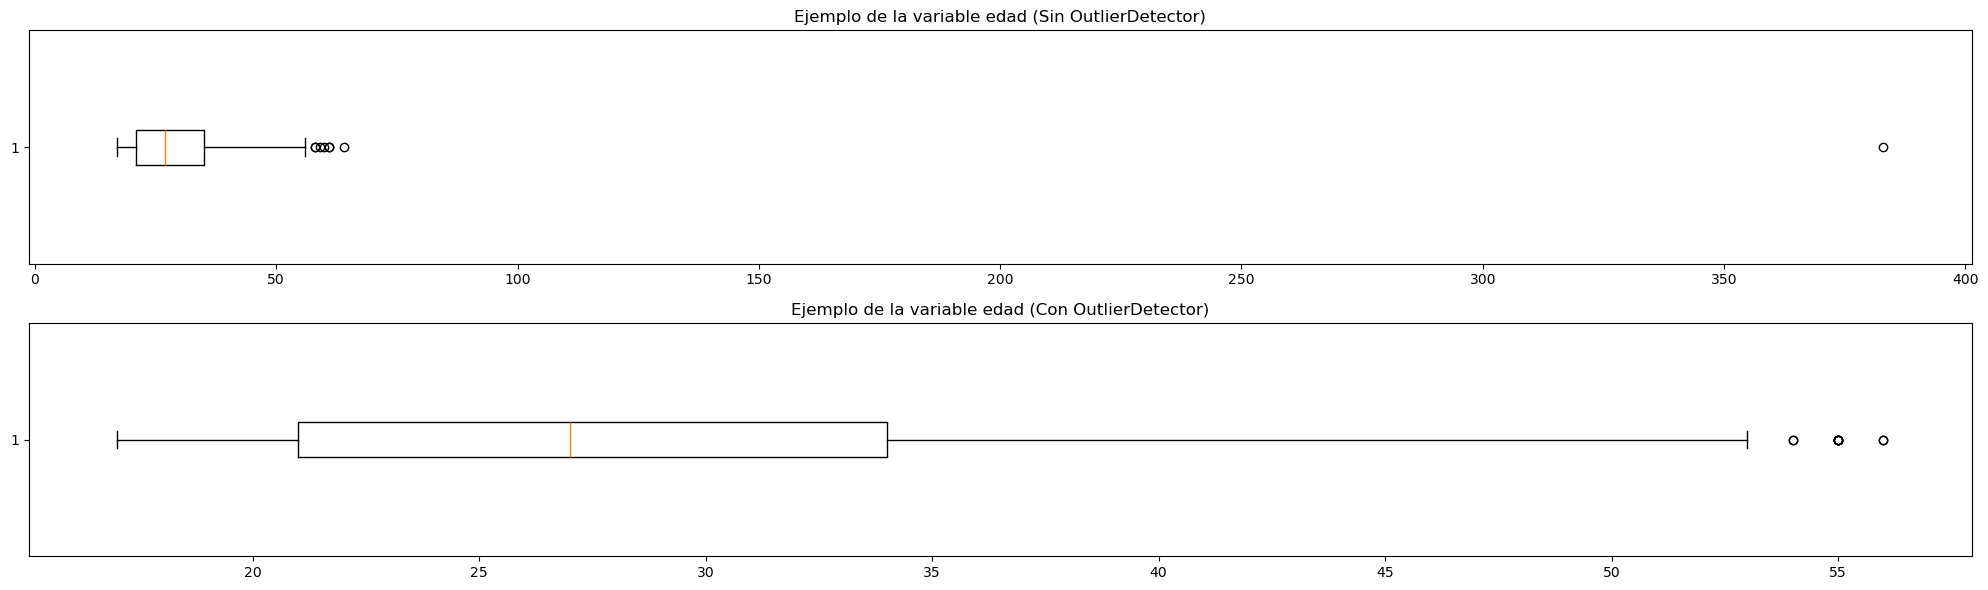

In [59]:
from sklearn.base import TransformerMixin, BaseEstimator
import numpy as np
import pandas as pd

class OutlierDetector(TransformerMixin, BaseEstimator):
	"""Detector y corrector de outliers por distintos métodos"""
	def __init__(self, k: float | None = 1.5, deteccion: str | None = "iqr", reemplazo: str | None = "mediana"):
		opciones_deteccion = ["iqr", "mediastd"]
		opciones_reemplazo = ["mediana", "media", "min", "max", "moda"]
        
		if deteccion not in opciones_deteccion:
			raise ValueError(f"[ERROR]: La opción de deteccion '{deteccion}' no está disponible. Usar solo [{', '.join(opciones_deteccion)}]")
		if reemplazo not in opciones_reemplazo:
			raise ValueError(f"[ERROR]: La opción de reemplazo '{reemplazo}' no está disponible. Usar solo [{', '.join(opciones_reemplazo)}]")
		
		self.stats = None
		self.modas = None
		self.columns = None
		self.mins = {}
		self.maxs = {}
		self.k = k
		self.deteccion = deteccion
		self.reemplazo = reemplazo

	def fit(self, X: pd.DataFrame, y: pd.DataFrame | None = None):
		if isinstance(X, np.ndarray):
			X = pd.DataFrame(X)
		if isinstance(y, np.ndarray):
			y = pd.DataFrame(y)

		self.stats = X.describe()
		# Evita columnas categoricas y columnas binarias
		self.columns = [column 
				  for column in X.columns 
				    if (X[column].dtype != object and 
			            len(np.unique(X[column].dropna())) > 2)]
				
		if self.reemplazo == "moda":
			self.modas = X.mode()
		elif self.reemplazo in ["min", "max"]: # Me guardo los minimos y maximos que NO sean outliers
			for column in self.columns:
				if self.deteccion == "iqr":
					Q1 = self.stats[column]["25%"]
					Q3 = self.stats[column]["75%"]
					IQR = Q3-Q1

					lim_sup = Q3 + self.k*IQR
					lim_inf = Q1 - self.k*IQR
				else: # mediastd
					media = self.stats[column]["mean"]
					std = self.stats[column]["std"]

					lim_sup = media + self.k * std
					lim_inf = media - self.k * std

				mask_sup = X[column] > lim_sup
				mask_inf = X[column] < lim_inf

				self.mins[column] = X.loc[~(mask_sup | mask_inf), column].min()
				self.maxs[column] = X.loc[~(mask_sup | mask_inf), column].max()

		return self
	
	def transform(self, X: pd.DataFrame):
		if isinstance(X, np.ndarray):
			Xaux = pd.DataFrame(X).copy()
		else:
			Xaux = X.copy()

		for column in self.columns:
			if self.deteccion == "iqr":
				Q1 = self.stats[column]["25%"]
				Q3 = self.stats[column]["75%"]
				IQR = Q3-Q1

				lim_sup = Q3 + self.k*IQR
				lim_inf = Q1 - self.k*IQR
			else:
				media = self.stats[column]["mean"]
				std = self.stats[column]["std"]

				lim_sup = media + self.k * std
				lim_inf = media - self.k * std

			mask_sup = Xaux[column] > lim_sup
			mask_inf = Xaux[column] < lim_inf

			if self.reemplazo == "mediana":
				value = self.stats[column]["50%"]
			elif self.reemplazo == "media":
				value = self.stats[column]["mean"]
			elif self.reemplazo == "moda":
				value = self.modas[column][0]
			elif self.reemplazo == "min":
				value = self.mins[column]
			elif self.reemplazo == "max":
				value = self.maxs[column]

			# TODO: Decidir que hacer con las columnas int
			if Xaux.loc[:, column].dtype == int:
				value = round(value)

			Xaux.loc[mask_sup, column] = value
			Xaux.loc[mask_inf, column] = value
		return Xaux
	
if __name__ == '__main__':
	df = pd.read_csv("Autism-Adult-Data.csv", delimiter=',')
	preparador = Preparador()
	df = preparador.preparar(df)

	imputer = Imputer()
	df = imputer.fit_transform(df)
	
	transformador = Transformador(metodo_cat_num="orden")
	df_sin_outlier_detector = transformador.fit_transform(df)

	outlier_detector = OutlierDetector(k=1.5, deteccion="iqr", reemplazo="mediana")
	df_con_outlier_detector = outlier_detector.fit_transform(df_sin_outlier_detector)

	fig, axes = plt.subplots(2, 1, figsize=(20, 6))
	axes[0].set_title("Ejemplo de la variable edad (Sin OutlierDetector)")
	axes[0].boxplot(df_sin_outlier_detector["age"], vert=False)
	axes[1].set_title("Ejemplo de la variable edad (Con OutlierDetector)")
	axes[1].boxplot(df_con_outlier_detector["age"], vert=False)
	plt.tight_layout()
	plt.show()

### Estandarizador

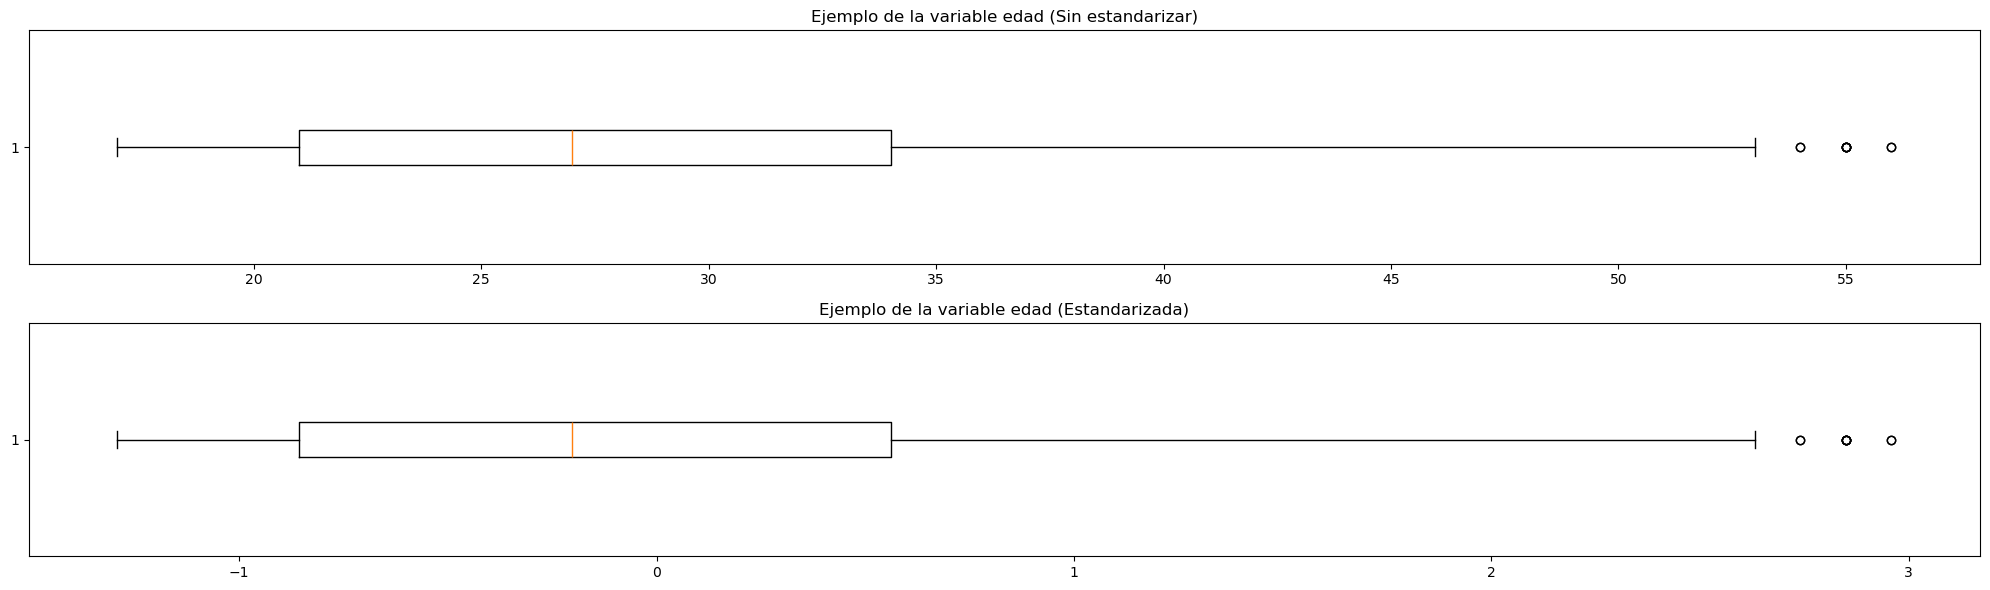

In [60]:
class Estandarizador(TransformerMixin, BaseEstimator):
    def __init__(self, metodo: Literal["minmax", "standard", "robust"]="standard") -> None:
        opciones = ["minmax", "standard", "robust"]
        
        if metodo not in opciones:
            raise ValueError(f"[ERROR]: La opción de estandarización '{metodo}' no está disponible. Usar solo [{', '.join(opciones)}]")
        
        self.metodo = metodo
        self._scaler = None

    def fit(self, X: pd.DataFrame, y=None):
        if self.metodo == "minmax":
            self._scaler = MinMaxScaler()
        elif self.metodo == "standard":
            self._scaler = StandardScaler()
        elif self.metodo == "robust":
            self._scaler = RobustScaler()

        self._scaler.fit(X)
        return self

    def transform(self, X: pd.DataFrame):
        return pd.DataFrame(self._scaler.transform(X), columns=X.columns, index=X.index)
    
if __name__ == '__main__':
    df = pd.read_csv("Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()
    df = preparador.preparar(df)

    imputer = Imputer()
    df = imputer.fit_transform(df)
    
    transformador = Transformador(metodo_cat_num="orden")
    df = transformador.fit_transform(df)

    outlier_detector = OutlierDetector(k=1.5, deteccion="iqr", reemplazo="mediana")
    df_sin_estandarizar = outlier_detector.fit_transform(df)

    estandarizador = Estandarizador(metodo="standard")
    df_estandarizado = estandarizador.fit_transform(df_sin_estandarizar)

    fig, axes = plt.subplots(2, 1, figsize=(20, 6))
    axes[0].set_title("Ejemplo de la variable edad (Sin estandarizar)")
    axes[0].boxplot(df_sin_estandarizar["age"], vert=False)
    axes[1].set_title("Ejemplo de la variable edad (Estandarizada)")
    axes[1].boxplot(df_estandarizado["age"], vert=False)
    plt.tight_layout()
    plt.show()

### Modelo

Para el modelo no crearemos nuestra propia clase porque usaremos el KNN y el Arbol de decisión, y como ya están programados en sklearn y cada uno tiene diferentes hiperparametros no nos complicaremos.

Debajo dejamos los hiperparametros de cada uno.

KNeighborsClassifier:
* n_neighbors
* weights: "uniform", "distance"
* metric: "manhattan", "euclidean"

DecisionTreeClassifier:
* criterion (Medida impureza nodo): "gini", "entropy"
* min_samples_split (Numero minimo ejemplos rama):
    * Valor entero: Se refiere exactamente al número de ejemplos
    * Valor real: Se refiere a la proporción de ejemplos
* min_samples_leaf (Numero minimo ejemplos hoja):
    * Valor entero: Se refiere exactamente al número de ejemplos
    * Valor real: Se refiere a la proporción de ejemplos
* max_depth
* ccp_alpha (Umbral alfa eficaz): Valor real.
* random_state

<a id="metricas"></a>
## 2.2 Métricas de validación y evaluación

### Método de validación


Usamos un enfoque de **Pipeline + GridSearchCV** porque este dataset tiene alrededor de **700 instancias**, un tamaño intermedio en el que podemos permitirnos validación cruzada sin que el coste computacional sea excesivo.

**Por qué Pipeline:**
- Encadena en un solo objeto todos los pasos de preprocesado y modelado (detección de outliers, escalado y clasificador).
- Evita data leakages al ajustar cada transformación solo con datos de entrenamiento y realizando la partición de validación de manera interna.
- Hace el flujo reproducible y mantenible.

**Por qué GridSearchCV:**
- Permite buscar sistemáticamente la mejor combinación de hiperparámetros del KNN (`n_neighbors`, `weights`, `p`).
- Es viable realizar una validación cruzada estratificada de 10 folds en este tamaño de datos.
- Devuelve el mejor modelo reentrenado y métricas por combinación para comparar y tomar decisiones.
- Dado que el espacio de búsqueda no es grande, es viable usar GridSearchCV en lugar de RandomizedSearch.

**Tenemos varios métodos de validación posibles:**
- Hold Out (estratificación y repetición)
- K-Fold (estratificación)
- Leave-One-Out

**Por qué StratifiedKFold:**
- En este problema de clasificación, la variable objetivo puede estar desbalanceada.
- `StratifiedKFold` mantiene la proporción de clases en cada fold, reduciendo varianza en la estimación y haciendo la evaluación más estable que un KFold simple.


### Método de evaluación

Tenemos varios métodos de evaluación posibles:
- Dependientes del umbral:
    - Accuracy
    - F1-score

- Independientes del umbral:
    - AUC de la curva ROC
    - AUC de la curva Precisión-Recall

### Métricas dependientes del umbral
Para las medidas dependientes del umbral el **accuracy** resulta deficiente para datasets con desbalanceo de clases porque no representa bien lo bueno que es el modelo en cada una de ellas, sino que lo hace de manera general, por lo que si hay una clase que predomina bastante más frente a otra, el modelo puede ser muy bueno en la clase mayoritaria y muy malo en clase minoritaria, y sin embargo, el accuracy saldría bastante alto. Por todo lo anterior, usaremos el **F1-score**, ya que tiene en cuenta el **recall** y la **precisión** por clase, así que es **mucho más robusto frente al desbalanceo de clases**.

Dado nuestro problema, donde tenemos que predecir si una persona es autista o no, nuestra solución busca minimizar los falsos negativos (es decir, evitar que el modelo clasifique a una persona autista como neurotípica), sin embargo, también **es importante mantener un balance entre la predicción de ambas clases**.
Por esta razón, se ha seleccionado el F1-score como métrica principal, dado que evalúa conjuntamente el Recall y la Precisión, asegurando sensibilidad ante los pacientes no detectados sin sacrificar la exactitud diagnóstica.

### Métricas independientes del umbral
Para las medidas independientes del umbral elegimos la **AUC de la curva Precisión-Recall** en vez de la AUC de la curva ROC. La razón es de coherencia con la métrica dependiente del umbral: el F1-score se calcula sobre la precisión y el recall de la clase positiva (autismo), y la curva Precisión-Recall mide exactamente ese mismo trade-off a lo largo de todos los umbrales posibles. La curva ROC, en cambio, mezcla el comportamiento sobre las dos clases (TPR vs FPR) y tiende a ser optimista cuando hay desbalance porque la clase mayoritaria ``infla'' el FPR. Aunque nuestro desbalance es moderado ($\approx$ 27/73), nos interesa más detectar bien los casos positivos que distinguir bien los negativos, así que tanto F1-score como AUC-PR apuntan al mismo objetivo y son comparables entre sí.


<a id="prototipos"></a>
## 2.3 Construcción de prototipos

In [61]:
nombre_componente_imputador = "imputador"
nombre_componente_transformador = "transformador"
nombre_componente_outlier = "outlier"
nombre_componente_estandarizador = "estandarizador"
nombre_componente_knn = "knn"
nombre_componente_arbol = "arbol"

In [62]:
param_grid_imputador = {
    f"{nombre_componente_imputador}__metodo_imputacion_vars_num": ["media", "mediana"],
    f"{nombre_componente_imputador}__metodo_imputacion_vars_cat": ["moda", "missing"]
}

param_grid_transformador = {
    f"{nombre_componente_transformador}__metodo_cat_num": ["orden", "conteo", "ohe", "binary"]
}

param_grid_outlier = {
    f"{nombre_componente_outlier}__k": [1.5, 3, 4.5],
    f"{nombre_componente_outlier}__deteccion": ["iqr", "mediastd"],
    f"{nombre_componente_outlier}__reemplazo": ["mediana", "media", "min", "max", "moda"]
}

param_grid_estandarizador = {
    f"{nombre_componente_estandarizador}__metodo": ["minmax", "standard", "robust"]
}

param_grid_knn = {
    f"{nombre_componente_knn}__n_neighbors": [3, 5, 7, 9, 11, 13],
    f"{nombre_componente_knn}__weights": ["uniform", "distance"],
    f"{nombre_componente_knn}__metric": ["manhattan", "euclidean"]
}

param_grid_arbol = {
    f"{nombre_componente_arbol}__criterion": ["gini", "entropy"],
    f"{nombre_componente_arbol}__min_samples_split": [10, 20, 50],
    f"{nombre_componente_arbol}__min_samples_leaf": [10, 20, 50],
    f"{nombre_componente_arbol}__max_depth": [5, 10],
    f"{nombre_componente_arbol}__ccp_alpha": [0, 0.01, 0.001]
}

In [63]:
def construir_prototipo_pipeline(
        imputador: Imputer=Imputer(),
        transformador: Transformador=Transformador(),
        outlier: OutlierDetector=None,
        estandarizador: Estandarizador=None,
        modelo: KNeighborsClassifier | DecisionTreeClassifier=KNeighborsClassifier(),
        invertir_orden_outlier_estandarizador: bool=False
    ) -> Pipeline:
    """ Se parte del pipeline base para agregarle los extras (Base = Imputador + Transformador) """

    pasos = [
        (nombre_componente_imputador, imputador),
        (nombre_componente_transformador, transformador)
    ]
    
    if not invertir_orden_outlier_estandarizador:
        if outlier is not None: pasos.append((nombre_componente_outlier, outlier))
        if estandarizador is not None: pasos.append((nombre_componente_estandarizador, estandarizador))
    else:
        if estandarizador is not None: pasos.append((nombre_componente_estandarizador, estandarizador))
        if outlier is not None: pasos.append((nombre_componente_outlier, outlier))
        
    
    if isinstance(modelo, KNeighborsClassifier):
        pasos.append((nombre_componente_knn, modelo))
    elif isinstance(modelo, DecisionTreeClassifier):
        pasos.append((nombre_componente_arbol, modelo))

    return Pipeline(pasos)

<a id="analisis"></a>
# 3. Análisis

En esta sección se irá construyendo el pipeline final poco a poco estudiando las mejores configuraciones para cada componente.

Como aclaración, la mejor forma de crear el pipeline, sería introducir todos los componentes y buscar la mejor configuración global
entre estos, sin embargo, esto es muy costoso, así que hemos optado por hacerlo de esta forma.

El flujo que realizaremos será el siguiente:
* Pipeline base: Buscar la mejor configuración del Imputador + Transformador. (Tiene el KNN por defecto)
* Pipeline base + Outlier Detector: Añadir a la pipeline base el detector de outliers para analizar el impacto.
* Pipeline base + Estandarizador: Añadir a la pipeline base el estandarizador para analizar el impacto.
* Pipeline avanzada: Agregar a la pipeline base el Outlier Detector y el Estandarizador con la mejor configuración.
* Pipeline avanzada + Modelo tuneado: Tunear el modelo de la pipeline avanzada.
* Pipeline avanzada + Umbral tuneado: Tunear el umbral de la pipeline avanzada.

A continuación, dejamos el scorer y el cv que utilizaremos.

In [64]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
scorer_dependiente_umbral = make_scorer(f1_score, response_method="predict", greater_is_better=True)
scorer_independiente_umbral = make_scorer(average_precision_score, response_method="predict_proba", greater_is_better=True)

In [65]:
def imprimir_resultados_grid(grid: GridSearchCV, nombres_componentes: list[str]):
    print("=======================")
    print("    Resultados")
    print("=======================\n")

    print("Componentes:")
    pipeline = grid.best_estimator_
    for nombre_componente in nombres_componentes:
        print(f"    {nombre_componente}:")

        componente = pipeline.named_steps[nombre_componente]
        for nombre_parametro, valor_parametro in componente.get_params().items():
            print(f"        {nombre_parametro}: {valor_parametro}")

    print("")
    print("Medidas:")
    print(f"    Score: {round(grid.best_score_, 4)}")

<a id="modelo_base"></a>
## 3.1 Análisis de la pipeline base

En este apartado, buscaremos la mejor configuración del Imputador + Transformador, usando el KNN por defecto como modelo base.

In [66]:
# Creamos la mejor pipeline base
pipeline = construir_prototipo_pipeline()

param_grid = param_grid_imputador | param_grid_transformador

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el mejor imputador y transformador
mejor_imputador = grid.best_estimator_.named_steps[nombre_componente_imputador]
mejor_transformador = grid.best_estimator_.named_steps[nombre_componente_transformador]

# Mostramos los resultados
nombres_componentes_mostrar = [
    nombre_componente_imputador,
    nombre_componente_transformador
]
imprimir_resultados_grid(grid, nombres_componentes_mostrar)

    Resultados

Componentes:
    imputador:
        metodo_imputacion_vars_cat: moda
        metodo_imputacion_vars_num: media
    transformador:
        metodo_cat_num: ohe

Medidas:
    Score: 0.9029


Como podemos ver, obtenemos un AUC-PR del 0.9029.

<a id="outliers"></a>
## 3.2 Análisis del componente OutlierDetector

En este siguiente apartado, analizaremos el impacto del OutlierDetector en la pipeline base.

In [67]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=OutlierDetector()
)

param_grid = param_grid_outlier
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Mostramos los resultados
imprimir_resultados_grid(grid, [nombre_componente_outlier])

/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 345, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home

    Resultados

Componentes:
    outlier:
        deteccion: mediastd
        k: 1.5
        reemplazo: moda

Medidas:
    Score: 0.9257


Como se puede ver observamos una pequeña mejora introduciendo este componente, ya que pasamos de 0.9029 a 0.9257.

<a id="estandarizador"></a>
## 3.3 Análisis del componente Estandarizador

En este otro apartado, analizaremos el impacto del Estandarizador en la pipeline base.

In [68]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    estandarizador=Estandarizador()
)

param_grid = param_grid_estandarizador
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Mostramos los resultados
imprimir_resultados_grid(grid, [nombre_componente_estandarizador])

    Resultados

Componentes:
    estandarizador:
        metodo: robust

Medidas:
    Score: 0.9488


Como se puede ver, observamos una mejora mayor con el Estandarizador que con el OutlierDetector, ya que ahora pasamos de 0.9029 a 0.9488.

Si tenemos que elegir entre alguno de los 2 componentes, nos quedaríamos con el Estandarizador.

<a id="pipeline_avanzada"></a>
## 3.4 Análisis de la pipeline avanzada

Como hemos podido ver en los anteriores experimentos es bueno introducir el OutlierDetector o el Estandarizador.

Por lo tanto, ahora introduciremos los 2 componentes en ordenes diferentes.

En cada orden encontraremos la mejor configuración entre ellos para crear una pipeline más avanzada.

### Orden: OutlierDetector -> Estandarizador

In [69]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=OutlierDetector(),
    estandarizador=Estandarizador()
)

param_grid = param_grid_outlier | param_grid_estandarizador
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el mejor outlier y estandarizador
mejor_outlier_orden_1 = grid.best_estimator_.named_steps[nombre_componente_outlier]
mejor_estandarizador_orden_1 = grid.best_estimator_.named_steps[nombre_componente_estandarizador]

# Mostramos los resultados
nombres_componentes_mostrar = [
    nombre_componente_imputador,
    nombre_componente_transformador,
    nombre_componente_outlier,
    nombre_componente_estandarizador
]
imprimir_resultados_grid(grid, nombres_componentes_mostrar)

/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nico/anaconda3/envs/py311ml/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 345, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home

    Resultados

Componentes:
    imputador:
        metodo_imputacion_vars_cat: moda
        metodo_imputacion_vars_num: media
    transformador:
        metodo_cat_num: ohe
    outlier:
        deteccion: mediastd
        k: 1.5
        reemplazo: moda
    estandarizador:
        metodo: robust

Medidas:
    Score: 0.9529


### Orden: Estandarizador -> OutlierDetector

In [70]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=OutlierDetector(),
    estandarizador=Estandarizador(),
    invertir_orden_outlier_estandarizador=True
)

param_grid = param_grid_outlier | param_grid_estandarizador
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el mejor outlier y estandarizador
mejor_outlier_orden_2 = grid.best_estimator_.named_steps[nombre_componente_outlier]
mejor_estandarizador_orden_2 = grid.best_estimator_.named_steps[nombre_componente_estandarizador]

# Mostramos los resultados
nombres_componentes_mostrar = [
    nombre_componente_imputador,
    nombre_componente_transformador,
    nombre_componente_outlier,
    nombre_componente_estandarizador
]
imprimir_resultados_grid(grid, nombres_componentes_mostrar)

/tmp/ipykernel_62352/2396686859.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.2662122994661331' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  Xaux.loc[mask_sup, column] = value
/tmp/ipykernel_62352/2396686859.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.2662122994661331' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  Xaux.loc[mask_sup, column] = value
/tmp/ipykernel_62352/2396686859.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.2662122994661331' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  Xaux.loc[mask_sup, column] = value
/tmp/ipykernel_62352/2396686859.py:103: FutureWarnin

    Resultados

Componentes:
    imputador:
        metodo_imputacion_vars_cat: moda
        metodo_imputacion_vars_num: media
    transformador:
        metodo_cat_num: ohe
    outlier:
        deteccion: mediastd
        k: 1.5
        reemplazo: mediana
    estandarizador:
        metodo: minmax

Medidas:
    Score: 0.9533


Como podemos apreciar, al introducir los 2 componentes en ordenes diferentes podemos ver que ambos tienen un rendimiento muy similar.

El mejor orden es tener primero el estandarizador y luego el detector de outliers, aunque creemos que no tiene sentido, porque
si el estandarizador utiliza como información los outliers, se puede crear un sesgo al normalizar con datos erróneos o muy fuera del rango. Probablemente, en este caso salga un poco superior la otra combinación simplemente por casualidad. De todas maneras, carece de sentido y la forma teóricamente correcta es la que usaremos.

El orden decidido es entonces: ... -> OutlierDetector -> Estandarizador -> ...

La máxima mejora que obteniamos hasta el momento era con el Estandarizador, dándonos un 0.9488, actualmente con la configuración anterior, obtenemos un 0.9533.

In [71]:
mejor_outlier = mejor_outlier_orden_1
mejor_estandarizador = mejor_estandarizador_orden_1
invertir_orden_outlier_estandarizador = False

Ya tenemos nuestra pipeline avanzada, en las siguientes secciones veremos si podemos sacarle mayor rendimiento.

<a id="modelo"></a>
## 3.5 Análisis del componente Modelo

En este apartado, encontraremos el mejor modelo y la mejor configuración de este en la pipeline avanzada.

### Modelo KNN

In [72]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=mejor_outlier,
    estandarizador=mejor_estandarizador,
    modelo=KNeighborsClassifier(),
    invertir_orden_outlier_estandarizador=invertir_orden_outlier_estandarizador
)

param_grid = param_grid_knn
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid_knn = grid.fit(X_resto, y_resto)

# Recogemos el componente
mejor_modelo_knn = grid.best_estimator_.named_steps[nombre_componente_knn]

# Mostramos los resultados
imprimir_resultados_grid(grid, [nombre_componente_knn])

    Resultados

Componentes:
    knn:
        algorithm: auto
        leaf_size: 30
        metric: manhattan
        metric_params: None
        n_jobs: None
        n_neighbors: 13
        p: 2
        weights: distance

Medidas:
    Score: 0.9777


Con el modelo de tipo KNN tuneado subimos de un 0.9533 a un 0.9777.

### Modelo Arbol de decisión

In [73]:
# Creamos la pipeline
pipeline = construir_prototipo_pipeline(
    imputador=mejor_imputador,
    transformador=mejor_transformador,
    outlier=mejor_outlier,
    estandarizador=mejor_estandarizador,
    modelo=DecisionTreeClassifier(),
    invertir_orden_outlier_estandarizador=invertir_orden_outlier_estandarizador
)

param_grid = param_grid_arbol
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_independiente_umbral,
    cv=cv
)

grid_arbol = grid.fit(X_resto, y_resto)

mejor_modelo_arbol = grid.best_estimator_.named_steps[nombre_componente_arbol]

# Mostramos los resultados
imprimir_resultados_grid(grid, [nombre_componente_arbol])

    Resultados

Componentes:
    arbol:
        ccp_alpha: 0
        class_weight: None
        criterion: entropy
        max_depth: 10
        max_features: None
        max_leaf_nodes: None
        min_impurity_decrease: 0.0
        min_samples_leaf: 10
        min_samples_split: 10
        min_weight_fraction_leaf: 0.0
        monotonic_cst: None
        random_state: None
        splitter: best

Medidas:
    Score: 0.83


Con el árbol de decisión, el rendimiento baja muchísimo, aunque lo más probable sea que al usar GridSearch, no estamos buscando donde toca,
por lo que deberíamos de utilizar RandomSearch para ganar mayor flexibilidad.

Por lo anterior, decidimos quedarnos con el KNN tuneado como modelo.

In [74]:
mejor_modelo = mejor_modelo_arbol if grid_arbol.best_score_ > grid_knn.best_score_ else mejor_modelo_knn

<a id="umbral"></a>
## 3.6 Análisis del umbral

Para analizar el umbral, usaremos la pipeline más avanzada, y con la medida dependiente del umbral escogeremos
aquel que la maximice.

Necesitaremos una clase en la que no habíamos pensado, pero la dejamos por aquí.

In [75]:
class ThresholdKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=0.5, n_neighbors=5, weights="uniform", metric="minkowski"):
        self.threshold = threshold
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric
        self.classes_ = None

    def fit(self, X, y):
        self.model_ = KNeighborsClassifier(
            n_neighbors=self.n_neighbors,
            weights=self.weights,
            metric=self.metric
        )
        self.model_.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        probas = self.model_.predict_proba(X)[:, 1]
        return (probas >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

In [76]:
# Creamos la pipeline
if not(invertir_orden_outlier_estandarizador):
    tercer_paso = (nombre_componente_outlier, mejor_outlier)
    cuarto_paso = (nombre_componente_estandarizador, mejor_estandarizador)
else:
    tercer_paso = (nombre_componente_estandarizador, mejor_estandarizador)
    cuarto_paso = (nombre_componente_outlier, mejor_outlier)

pipeline = Pipeline([
    (nombre_componente_imputador, mejor_imputador),
    (nombre_componente_transformador, mejor_transformador),
    tercer_paso,
    cuarto_paso,
    ("thresholdKNN", ThresholdKNN(metric=mejor_modelo.metric, n_neighbors=mejor_modelo.n_neighbors, weights=mejor_modelo.weights)) # Ponemos el mejor KNN configurado
])
    
param_grid = {
    "thresholdKNN__threshold": np.arange(0, 1, step=0.05)
}
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer_dependiente_umbral,
    cv=cv
)

grid.fit(X_resto, y_resto)

# Recogemos el mejor ThresholdKNN
mejor_thresholdKNN = grid.best_estimator_.named_steps["thresholdKNN"]

# Mostramos los resultados
imprimir_resultados_grid(grid, ["thresholdKNN"])

    Resultados

Componentes:
    thresholdKNN:
        metric: manhattan
        n_neighbors: 13
        threshold: 0.45
        weights: distance

Medidas:
    Score: 0.9148


Como se puede observar, el mejor umbral queda guardado en `mejor_thresholdKNN` para usarlo en la pipeline final.

<a id="mejor_pipeline"></a>
## 3.7 Mejor pipeline

Realizados los anteriores experimentos, podemos llegar al siguiente resultado.

In [77]:
if not(invertir_orden_outlier_estandarizador):
    tercer_paso = (nombre_componente_outlier, mejor_outlier)
    cuarto_paso = (nombre_componente_estandarizador, mejor_estandarizador)
else:
    tercer_paso = (nombre_componente_estandarizador, mejor_estandarizador)
    cuarto_paso = (nombre_componente_outlier, mejor_outlier)

mejor_pipeline = Pipeline([
    (nombre_componente_imputador, mejor_imputador),
    (nombre_componente_transformador, mejor_transformador),
    tercer_paso,
    cuarto_paso,
    ("thresholdKNN", mejor_thresholdKNN),
])

In [78]:
mejor_pipeline.fit(X_resto, y_resto)

Pipeline(steps=[('imputador',
                 Imputer(metodo_imputacion_vars_cat='moda',
                         metodo_imputacion_vars_num='media')),
                ('transformador', Transformador(metodo_cat_num='ohe')),
                ('outlier',
                 OutlierDetector(deteccion='mediastd', reemplazo='moda')),
                ('estandarizador', Estandarizador(metodo='robust')),
                ('thresholdKNN',
                 ThresholdKNN(metric='manhattan', n_neighbors=13,
                              threshold=0.45, weights='distance'))])

### Interpretabilidad global del modelo

Una vez que hemos obtenido la mejor pipeline para nuestro problema, vamos a interpretar la influencia de cada variable en las predicciones finales.

In [ ]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# idx = 5
# example = X_test.loc[X_test.index[idx]]

# kernel_explainer = shap.KernelExplainer(mejor_pipeline.predict_proba, X_resto)
# kernel_shap_values = kernel_explainer.shap_values(example)

# shap.initjs()
# shap.force_plot(kernel_explainer.expected_value[1], kernel_shap_values[:, 1], example)

# No podemos hacer esto porque tenemos preprocesadas las columnas y aparecen muchisimas columnas por el one-hot encoding.
# Usamos los demás graficos (borrar estos comentarios dsp, es para que lo vean ustedes)


# Obtenemos la importancia de cada variable
result = permutation_importance(mejor_pipeline, X_resto, y_resto, scoring='f1', random_state=seed) 
# Obtenemos los índices de las variables ordenadas de mayor a menor
sorted_importances_idx = result.importances_mean.argsort()

# Creamos un DataFrame con toda la información y lo mostramos
feature_importances = pd.DataFrame([], index = X_resto.columns[sorted_importances_idx[::-1]], columns=['Media','Desviación Estándard'])
feature_importances['Media'] = result.importances_mean[sorted_importances_idx[::-1]]
feature_importances['Desviación Estándard'] = result.importances_std[sorted_importances_idx[::-1]]
print(feature_importances)

importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_resto.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in f1-score")
ax.figure.tight_layout()
plt.show()


PartialDependenceDisplay.from_estimator(mejor_pipeline, X_resto, [['age']], grid_resolution=30, target=1)


# Calculamos los valores SHAP para obtener la importancia global de cada variable en el modelo
# SHAP transforma los datos internamente a array, por eso reconstruimos el DataFrame con sus columnas.
def predict_proba_shap(X):
    Xaux = pd.DataFrame(X, columns=X_resto.columns)

    for col in X_resto.select_dtypes(include="category").columns:
        Xaux[col] = Xaux[col].astype("category")

    for col in X_resto.select_dtypes(exclude="category").columns:
        Xaux[col] = pd.to_numeric(Xaux[col], errors="coerce").astype(X_resto[col].dtype)

    return mejor_pipeline.predict_proba(Xaux)

X_shap_background = shap.sample(X_resto, 50, random_state=seed)
shap_values = shap.KernelExplainer(predict_proba_shap, X_shap_background).shap_values(X_resto)

if isinstance(shap_values, list):
    shap_values_clase_positiva = shap_values[1]
else:
    shap_values_clase_positiva = shap_values[:, :, 1]

# Mostramos el resultados sin agrupar: sin hacer un gráfico de barras
    # En caso de problemas de regresión se mostraría shap_values
shap.summary_plot(shap_values_clase_positiva, X_resto)

# # Calculamos los valores SHAP para obtener la importancia global de cada variable en el modelo
# shap_values = shap.TreeExplainer(mejor_pipeline.predict_proba, X_resto_transform).shap_values(shap.sample(X_resto_transform, 4))
# # Mostramos el resultado en un gráfico de barras (plot_type="bar")
# shap.summary_plot(shap_values[:, :, 1], X_resto, plot_type="bar")



<a id="experimentos"></a>
# 4. Experimentos

En este punto realizaremos 2 experimentos con nuestra mejor pipeline.

<a id="experimento_test"></a>
## 4.1 Experimento en test

Vamos a observar que tal rinde nuestra pipeline en el conjunto de test.

In [80]:
y_preds = mejor_pipeline.predict(X_test)
y_probas = mejor_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
auc_pr = average_precision_score(y_test, y_probas)
matriz_confusion = confusion_matrix(y_test, y_preds)

print("Accuracy: ", acc)
print("F1-score: ", f1)
print("AUC-PR: ", auc_pr)
print("Matriz de confusión: ")
print(matriz_confusion)

Accuracy:  0.9929078014184397
F1-score:  0.987012987012987
AUC-PR:  0.9993252361673415
Matriz de confusión: 
[[102   1]
 [  0  38]]


<a id="experimento_nosotros"></a>
## 4.2 Experimento con nosotros

A continuación, cada uno de nosotros rellenará el cuestionario y veremos los resultados.

__Cuestionario__  
* I often notice small sounds when others do not: agree, disagree  
* I usually concentrate more on the whole picture, rather than the small details: agree, disagree  
* I find it easy to do more than one thing at once: agree, disagree  
* If there is an interruption, I can switch back to what I was doing very quickly: agree, disagree  
* I find it easy to read between the lines when someone is talking to me: agree, disagree  
* I know how to tell if someone listening to me is getting bored: agree, disagree  
* When I’m reading a story, I find it difficult to work out the characters’ intentions: agree, disagree  
* I like to collect information about categories of things: agree, disagree  
* I find it easy to work out what someone is thinking or feeling just by looking at their face: agree, disagree  
* I find it difficult to work out people’s intentions: agree, disagree  
* Age: Number  
* Gender: f, m  
* Ethnicity: asian, black, hispanic, latino, middleeastern, others, pasifika, southasian, turkish, white-european  
* Jaundice (Ictericia): yes, no  
* Family pdd: yes, no  
* Country of residence: Your country  
* Used app before: yes, no

__Respuestas__
| Pregunta | Juan | Nico | Eloy |
|---|---|---|---|
| P1 |  |  |  |
| P2 |  |  |  |
| P3 |  |  |  |
| P4 |  |  |  |
| P5 |  |  |  |
| P6 |  |  |  |
| P7 |  |  |  |
| P8 |  |  |  |
| P9 |  |  |  |
| P10 |  |  |  |
| age |  |  |  |
| gender |  |  |  |
| ethnicity |  |  |  |
| jaundice |  |  |  |
| family_pdd |  |  |  |
| country_of_res |  |  |  |
| used_app_before |  |  |  |

In [81]:
juan = ['disagree', 'disagree', 'disagree', 'disagree', 'agree', 'agree', 'disagree', 'disagree', 'agree', 'disagree',
        21, 'm', 'latino', 'no', 'no', 'colombia', 'no']
nico = ['disagree', 'agree', 'disagree', 'disagree', 'disagree', 'agree', 'disagree', 'disagree', 'disagree', 'agree',
        23, 'm', 'white-european', 'no', 'no', 'argentina', 'no']
eloy = ["disagree", "agree", "agree", "disagree", "disagree", "agree", "disagree", "disagree","agree", "disagree", 
        20, "m", "hispanic", "no", "no", "spain", "no"]

otra_gente = [ # TODO: ELIMINAR COMENTARIOS QUE DICEN QUIEN ES QUIEN
    ['disagree', 'disagree', 'disagree', 'agree', 'agree', 'agree', 'disagree', 'disagree', 'disagree', 'disagree', 20, 'm', 'hispanic', 'no', 'no', 'spain', 'no'], #telmo
    ['agree', 'agree', 'disagree', 'disagree', 'disagree', 'disagree', 'agree', 'agree', 'disagree', 'agree', 20, 'm', 'hispanic', 'no', 'no', 'spain', 'no'], #pablo
    ['agree', 'agree', 'disagree', 'disagree', 'agree', 'agree', 'disagree', 'disagree', 'agree', 'disagree', 21, 'f', 'latino', 'no', 'no', 'spain', 'no'], #rosi
    ['disagree', 'disagree', 'agree', 'agree', 'agree', 'disagree', 'agree', 'disagree', 'agree', 'agree', 21, 'm', 'asian', 'no', 'no', 'spain', 'no'], #chen
    ['disagree', 'disagree', 'agree', 'agree', 'agree', 'agree', 'disagree', 'agree', 'agree', 'disagree', 21, 'm', 'white-european', 'no', 'no', 'spain', 'no'], #tiago
    ['disagree', 'agree', 'agree', 'agree', 'agree', 'agree', 'disagree', 'agree', 'agree', 'disagree', 20, 'm', 'hispanic', 'no', 'no', 'spain', 'no'], #danel
]

Vamos a analizar qué piensa el modelo, utilizando la mejor combinacion de componentes + hiperparámetros obtenida, sobre nuestras características, a ver si predice que tenemos autismo.

In [82]:
nosotros = pd.DataFrame([juan, nico, eloy], columns=X_resto.columns)
preds = mejor_pipeline.predict(nosotros)

otros = pd.DataFrame(otra_gente, columns=X_resto.columns, index=["telmo", "pablo", "rosi", "chen", "tiago", "danel"])
preds_otros = mejor_pipeline.predict(otros)
print("=========================")
print("      Predicciones")
print("=========================")

print("Juan: ", preds[0])
print("Nico: ", preds[1])
print("Eloy: ", preds[2])

print("otros")
for pred in preds_otros:
    print(pred)

      Predicciones
Juan:  0
Nico:  0
Eloy:  0
otros
0
1
0
0
0
0


/tmp/ipykernel_62352/1468461499.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29.053476333618164' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_num[nombre_columna]
/tmp/ipykernel_62352/1468461499.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29.053476333618164' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_num[nombre_columna]


Como anteriormente no ha dado positivo nadie, nos vemos obligados a calcular el grado de autismo de cada uno.

In [83]:
preds = mejor_pipeline.predict_proba(nosotros)
preds_otros_proba = mejor_pipeline.predict_proba(otros)


print("=========================")
print("      Predicciones")
print("=========================")

print("Juan: ", preds[0, 1])
print("Nico: ", preds[1, 1])
print("Eloy: ", preds[2, 1])


print("otros")
for pred in preds_otros_proba:
    print(pred[1])

      Predicciones
Juan:  0.0
Nico:  0.14877258856081513
Eloy:  0.0
otros
0.0
1.0
0.0
0.0
0.0
0.0


/tmp/ipykernel_62352/1468461499.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29.053476333618164' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_num[nombre_columna]
/tmp/ipykernel_62352/1468461499.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29.053476333618164' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xaux.loc[Xaux[nombre_columna].isna(), nombre_columna] = self._valores_imputacion_vars_num[nombre_columna]


<a id="conclusiones"></a>
# 5. Conclusiones

En este trabajo, hemos encontrado un pipeline capaz de predecir el autismo en personas.

Para ello, hemos realizado varias cosas:
* Analizar nuestro dataset.
* Encontrar la mejor pipeline.
* Probar el pipeline con el conjunto de test.

A la hora de analizar nuestro dataset, hemos estudiado la relación de las variables de entrada con la de
salida, dando lugar a la eliminación de una de estas por poco aporte de información.

Posteriormente, para encontrar el mejor pipeline, hemos partido de uno básico, con el fin de mejorarlo añadiéndole
más componentes y configurando el umbral.

Por último, hemos probado dicho pipeline con el conjunto de test, obteniendo un 99.29% de accuracy.

En conclusión, el pipeline creado para la resolución de nuestro problema es bastante bueno.